# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Load models

### Normal

In [2]:
models_path = Path("/g/stegle/aalsayah/repos/data/models_obj")

In [3]:
model= mfl.MOFAFLEX.load(models_path / 'crc_222.hdf5')

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### SnS

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_110/Normal.SnS/crc_110.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

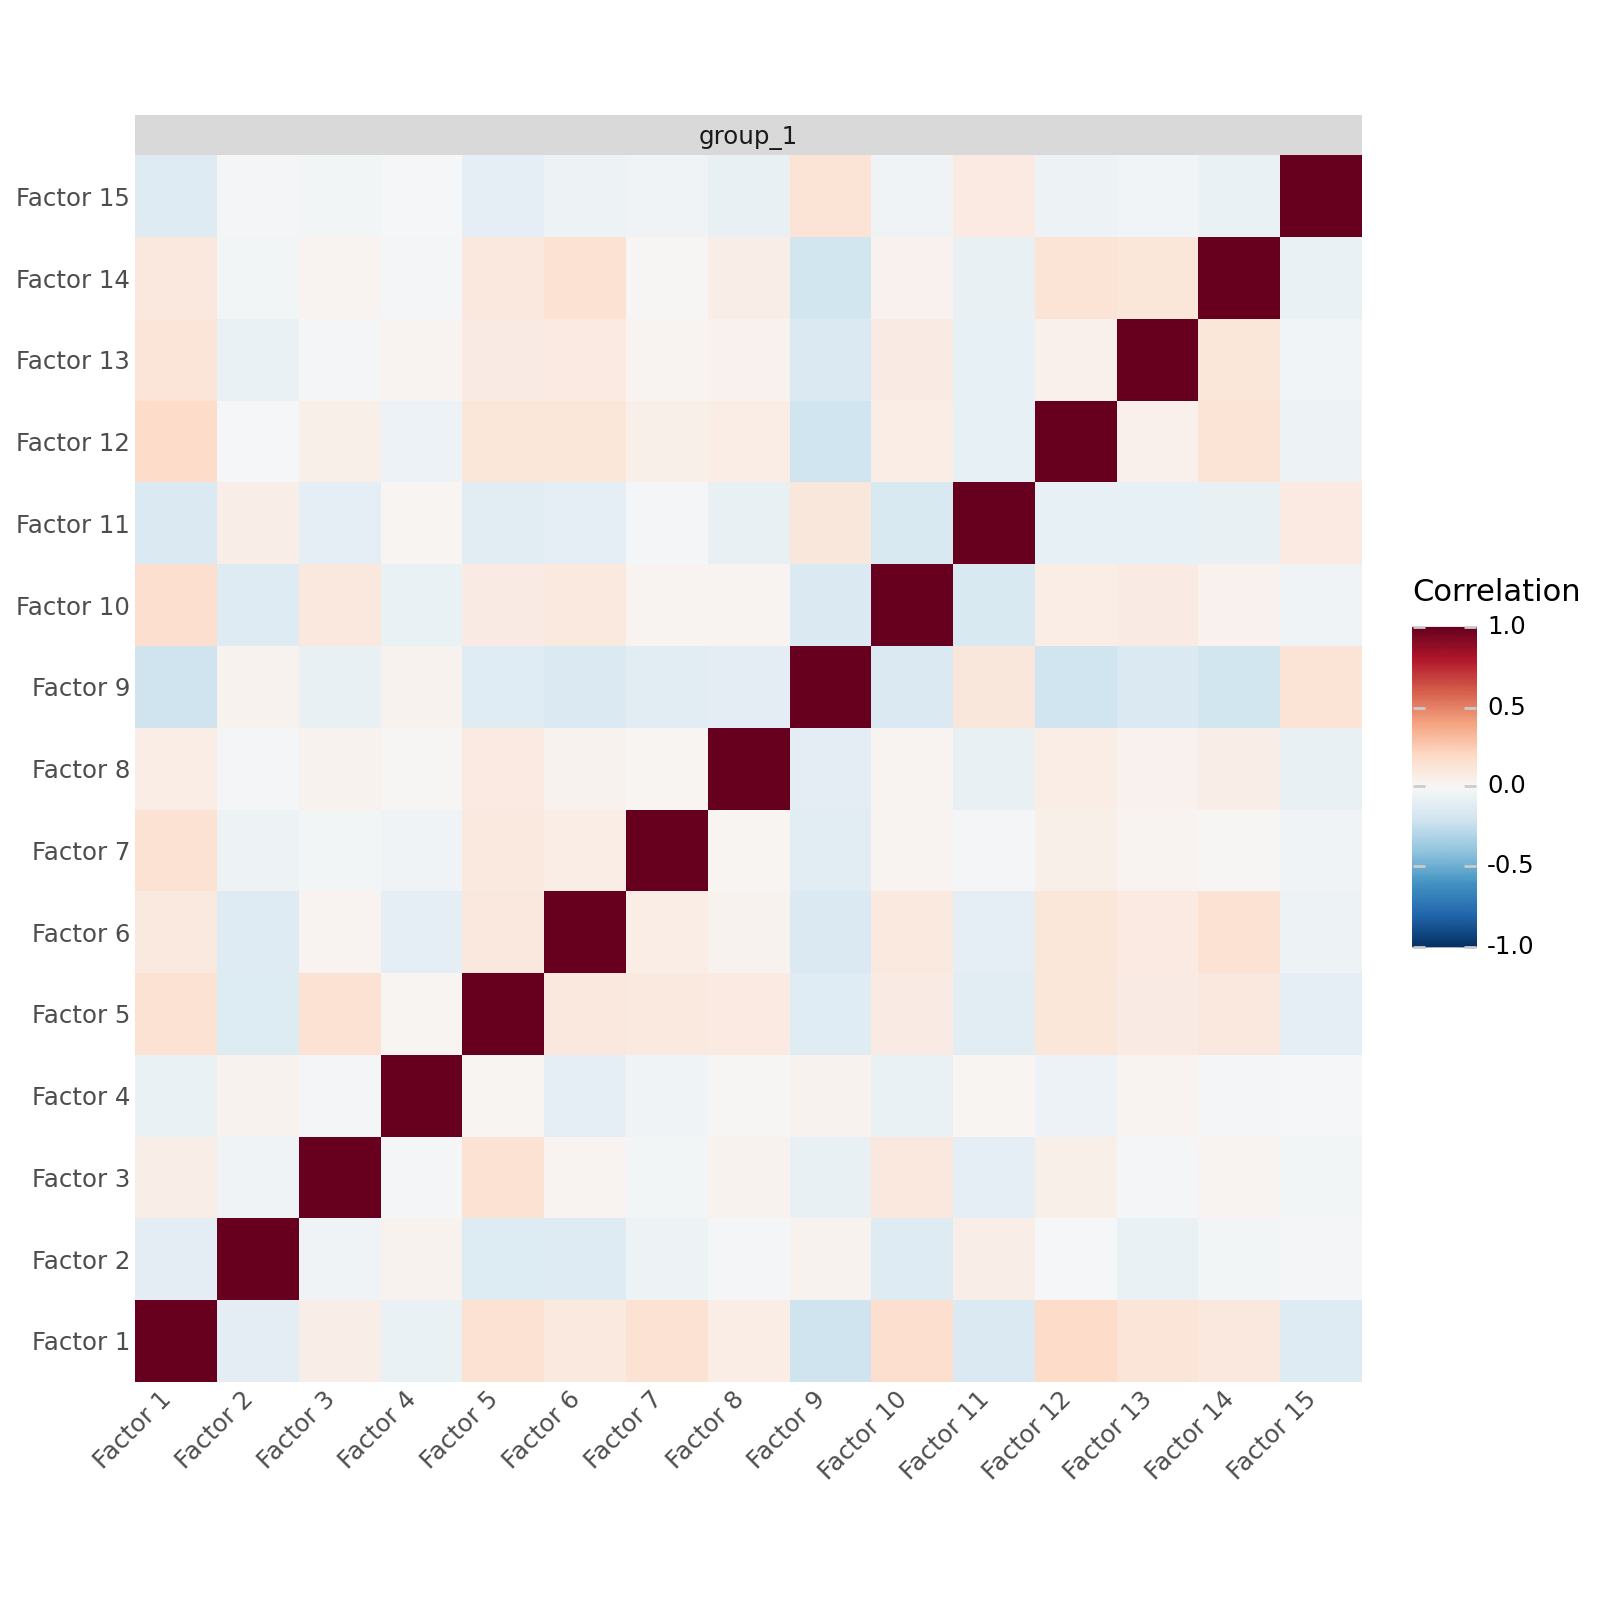

In [4]:
mfl.pl.factor_correlation(model)

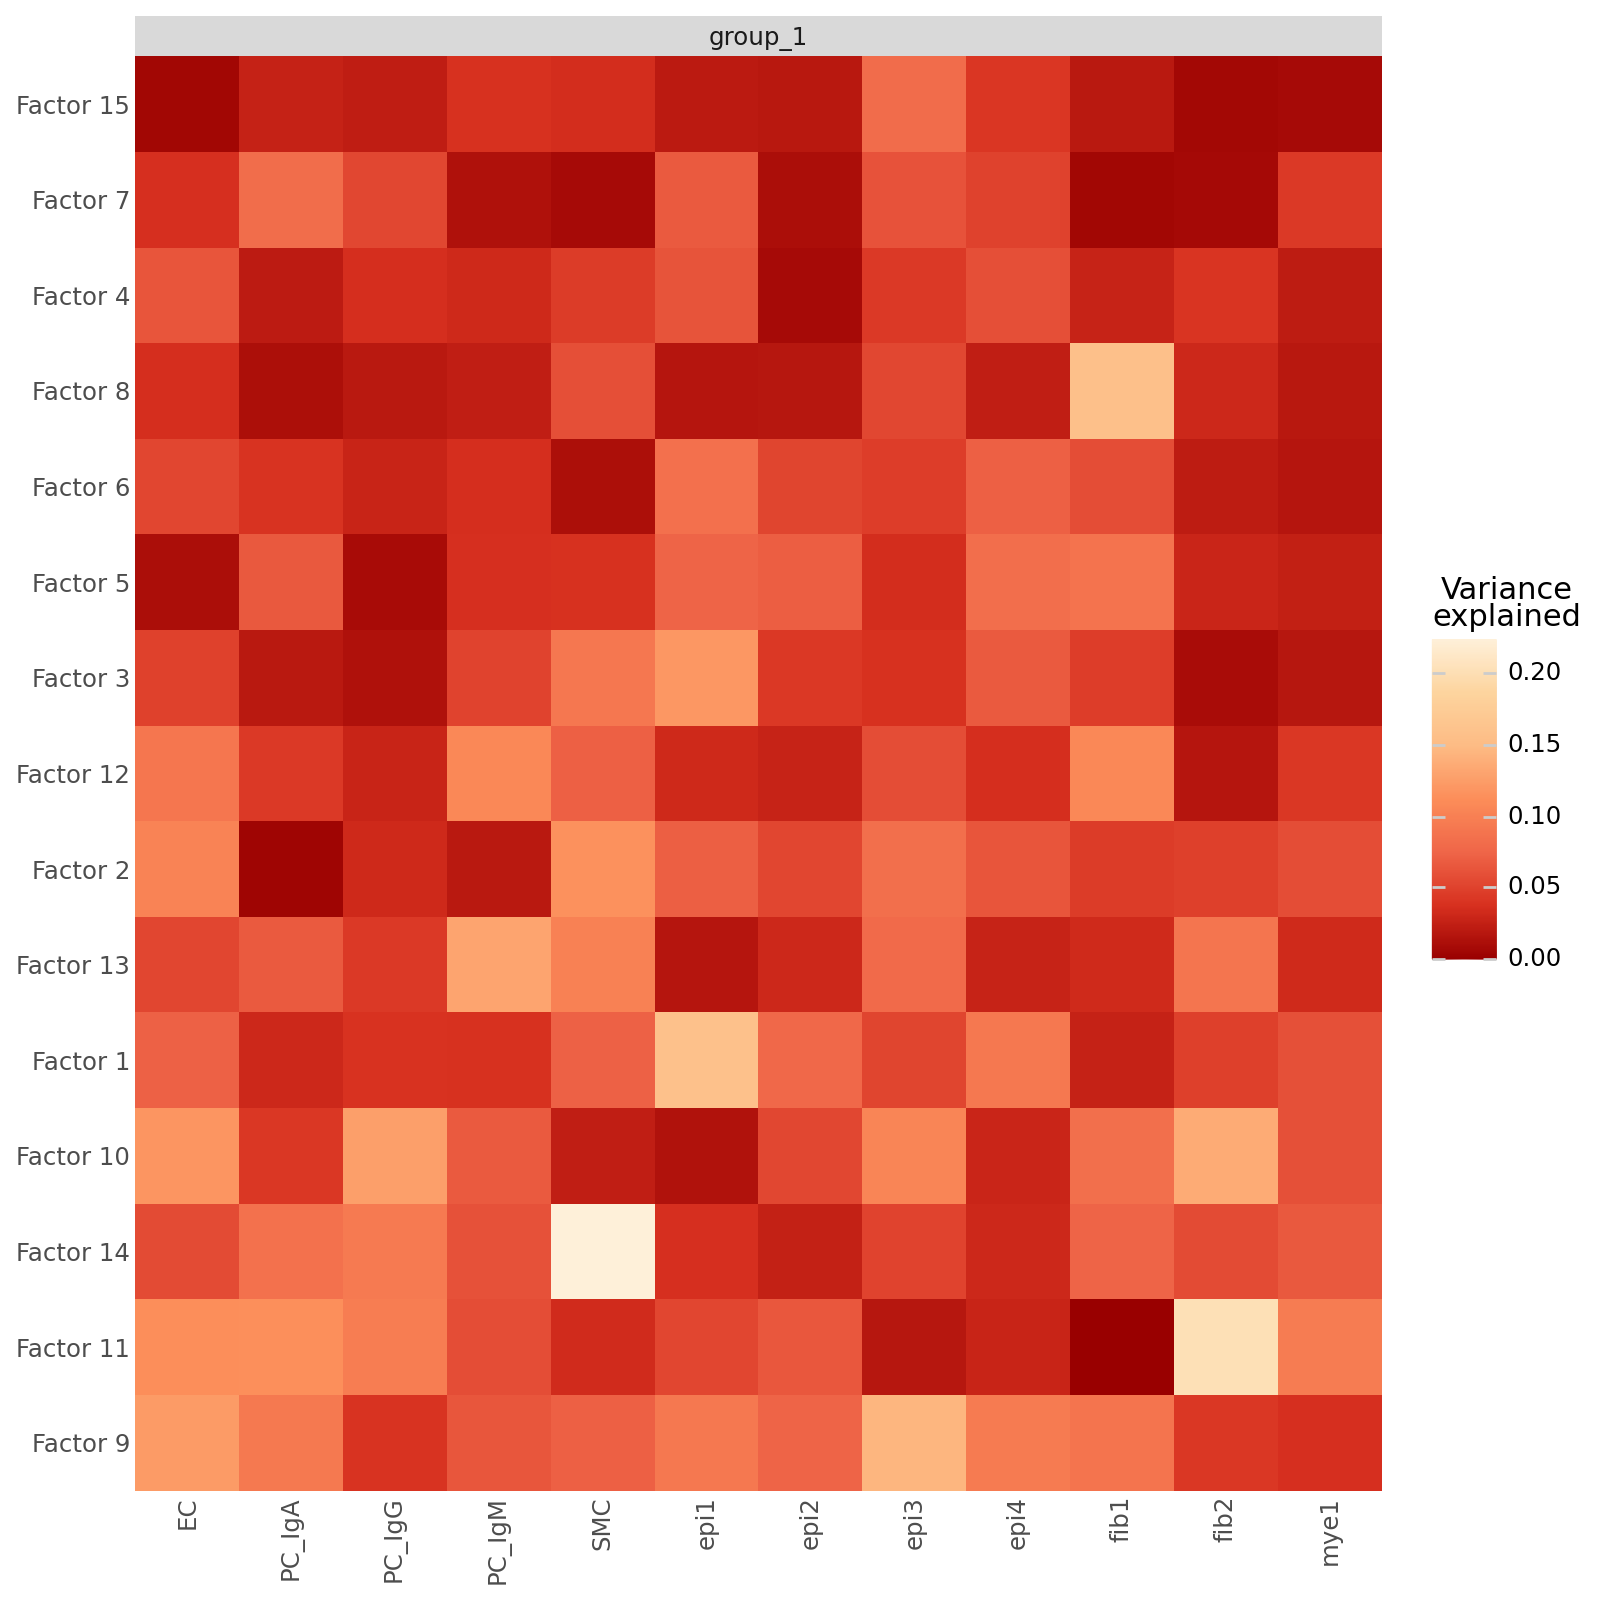

In [6]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [7]:
print(model.get_r2(total=True))

         group_1
epi4    0.785815
epi2    0.496613
mye1    0.516533
fib2    0.635922
EC      0.885059
PC_IgA  0.715494
PC_IgG  0.633231
epi1    0.825873
SMC     0.922065
fib1    0.785474
PC_IgM  0.631203
epi3    0.854514


In [8]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

0.723983059624789

## 3.Weights dist

In [9]:
weights_dict= model.get_weights()

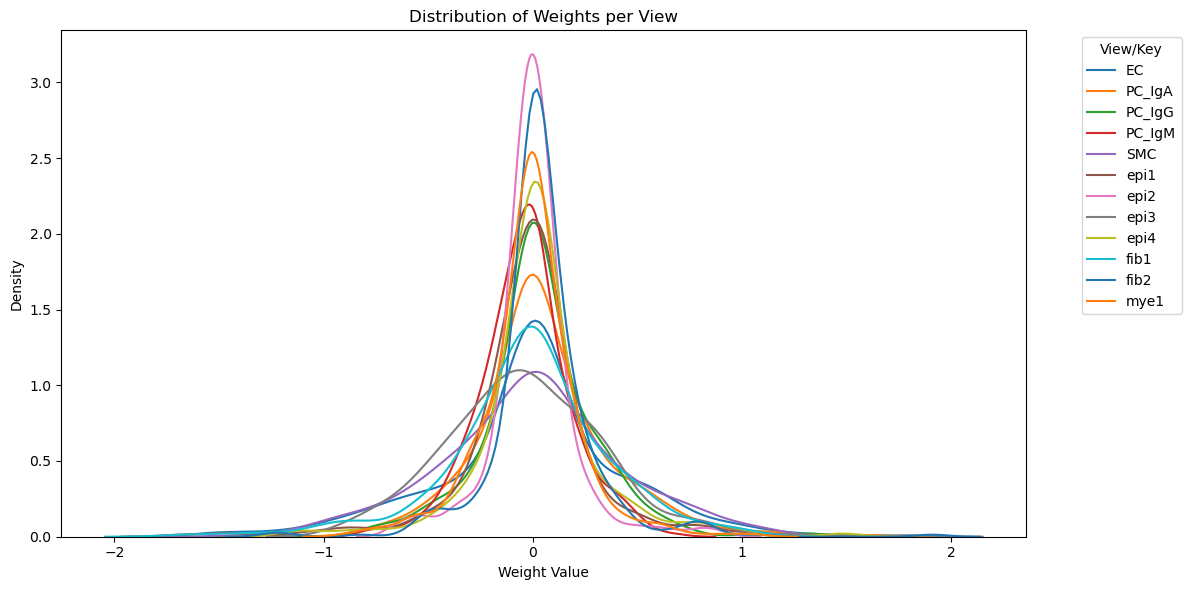

In [10]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [12]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [13]:
weights = model.get_weights()

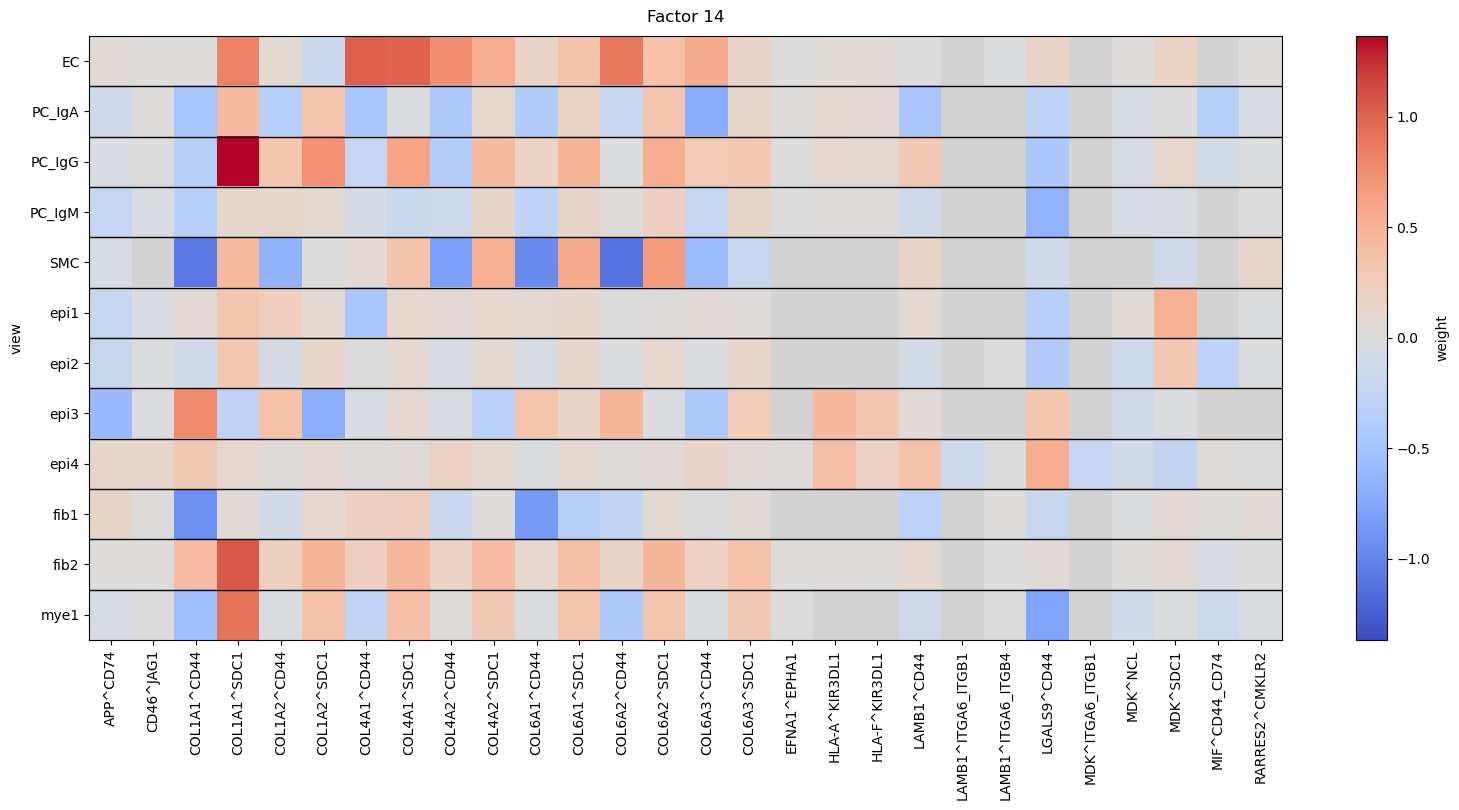

In [14]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 14

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [44]:
factors = model.get_factors()
factors = factors["group_1"]

In [45]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_2_127_422,0.387871,-0.049800,0.517704,-0.017365,0.585652,-0.228307,0.315696,0.697233,-0.124617,-0.173342,-0.291920,-0.128436,-0.093304,0.313443,-0.089024
c_2_127_634,-0.145322,0.151763,0.337174,-0.261542,0.516653,-0.057665,-0.083295,0.414080,0.048464,0.110271,-0.420316,-0.197219,0.078186,0.179523,0.282012
c_2_129_104,-0.046682,0.509435,-0.002031,-0.221346,-0.331794,0.000412,0.402205,-0.019110,0.393719,-0.008660,-0.010050,0.136046,-1.037196,-0.251961,0.015703
c_2_129_218,0.241796,-0.118587,0.537662,-1.005544,-0.164017,-0.138691,0.412200,-0.606718,-0.084703,0.538009,-0.280231,-0.374168,0.315284,-0.390313,-0.172315
c_2_129_292,0.103770,-0.099664,-0.128290,-0.792835,-1.364270,0.279831,0.230984,0.122961,0.575021,-0.845551,-0.040353,-0.162828,-1.294670,0.143663,-0.881322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_2_152_1629,0.599646,-0.632920,0.564470,0.532310,-0.057799,0.261982,-0.695996,1.526677,-0.241684,0.990544,-0.048867,0.518200,-0.217935,0.578892,0.891417
c_2_166_303,-0.338912,-0.483790,0.065757,-0.324964,0.112175,-0.172332,0.381004,0.115844,-0.301344,0.533272,0.096933,-0.012793,0.904312,-0.433132,-0.047566
c_2_166_314,-0.303443,-0.381950,-0.002528,-0.319237,0.216420,-0.153487,0.321940,0.028511,-0.346160,0.658987,0.224781,-0.045202,0.872569,-0.300552,-0.074024
c_2_166_348,0.028862,-0.749339,0.178761,0.140450,-0.096400,-0.137896,0.598281,0.388333,-0.244601,-0.189734,-0.161628,-0.228564,0.480578,-0.640653,0.124396


### Load lrdata

In [18]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_222_lrdata.h5ad")

In [19]:
lv1 = lrdata.obs["lv1"]
lv2 = lrdata.obs["lv2"]
ist = lrdata.obs["ist"]
typ = lrdata.obs["typ"]

In [46]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(19143,)

## UMAP

In [21]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [22]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [23]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [24]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}") #clusters=8, noise=53.50%

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=8, noise=53.50%


#### 2D UMAP

In [25]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [26]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

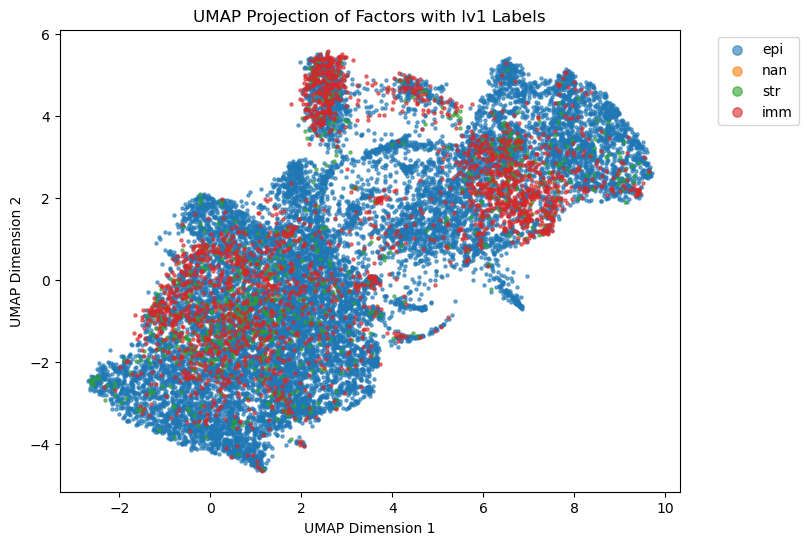

In [47]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

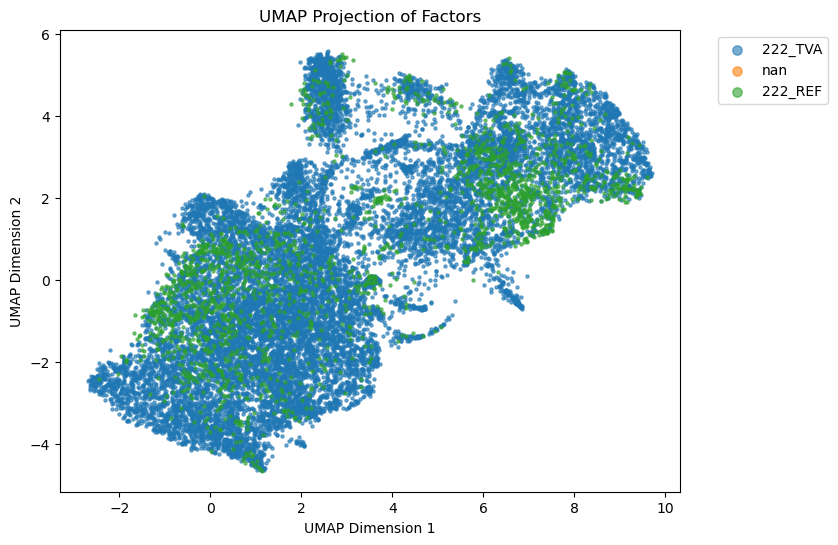

In [48]:
df_umap['Label'] = typ.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

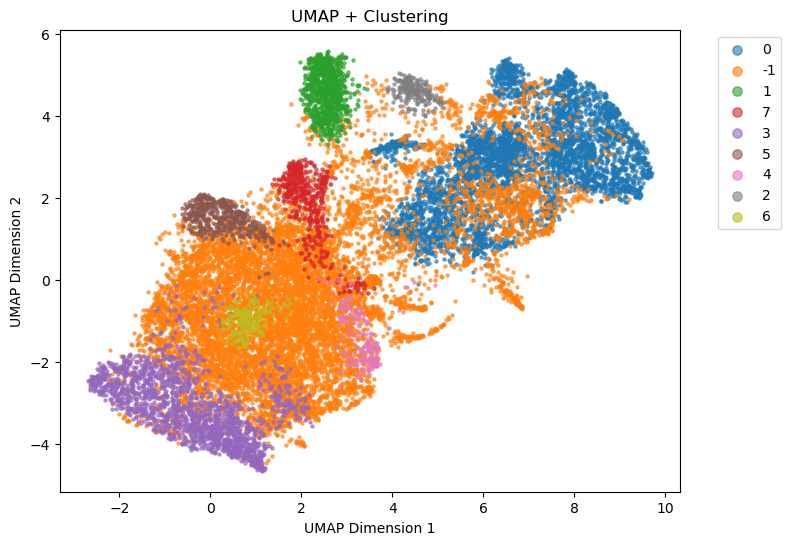

In [49]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Regression Model

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [66]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["typ"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [67]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_2_127_1003,-0.028897,-0.244317,0.452939,-0.012324,-0.101367,1.155526,-0.886801,-0.304043,0.781292,0.203467,0.038883,-0.378623,0.162139,-0.621923,-0.341787
c_2_127_1008,-0.304447,-0.946802,-0.206945,1.140865,-0.572715,-0.485902,-0.285983,-0.590444,-0.542373,-1.131108,-0.213289,-0.049617,0.427119,-0.252335,-0.402230
c_2_127_1032,0.444315,0.764443,-0.170191,0.180107,-0.443259,-0.408928,0.810669,-0.383647,-1.010566,-0.349460,0.219795,0.100779,-0.943125,-1.006581,-0.351284
c_2_127_1038,0.394829,0.927397,-0.286112,0.183226,-0.574950,-0.511821,1.083380,-0.195601,-1.148514,-0.530683,0.575999,0.067601,-0.844762,-1.118142,-0.339564
c_2_127_1040,0.405894,-1.002254,-0.057351,1.270241,-0.165995,0.568238,0.597876,0.583253,0.681364,1.179259,-0.513898,0.678052,0.983063,-0.833641,0.718129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_2_205_952,0.927602,-0.656198,0.971308,-1.826322,1.106469,0.788660,1.206380,2.213451,-1.012539,0.618896,0.808792,1.246389,0.292182,2.383515,0.268315
c_2_205_968,-0.239219,-0.124152,-0.269798,-0.134685,-0.612264,0.434893,-0.574945,0.410779,0.490149,0.168774,-0.758339,-0.140024,-1.053370,-0.480991,-0.071930
c_2_205_970,0.116418,-0.677394,1.204326,-0.663596,0.640648,0.446246,0.673215,1.441088,-0.040982,0.329436,-0.214226,0.345300,-0.025807,1.175537,0.422145
c_2_205_982,-0.952593,1.950037,-0.020362,0.732078,0.180029,-0.644461,0.421786,0.476985,0.949628,0.828529,-0.684818,-0.432099,-0.769116,-0.707263,0.742727


In [68]:
filtered_cell_types

c_2_127_1003        NaN
c_2_127_1008    222_TVA
c_2_127_1032    222_TVA
c_2_127_1038    222_TVA
c_2_127_1040    222_TVA
                 ...   
c_2_205_952     222_REF
c_2_205_968     222_REF
c_2_205_970     222_REF
c_2_205_982     222_REF
c_2_205_995     222_REF
Name: typ, Length: 19143, dtype: category
Categories (2, object): ['222_REF', '222_TVA']

In [69]:
X = F.values
y = filtered_cell_types.values  # labels

In [70]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [71]:
print(X.shape, y.shape)

(18606, 15) (18606,)


In [72]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -4.437245
Max: 4.400377
Mean: 0.0030754046
Median: -0.00027084572
Std dev: 0.6987784


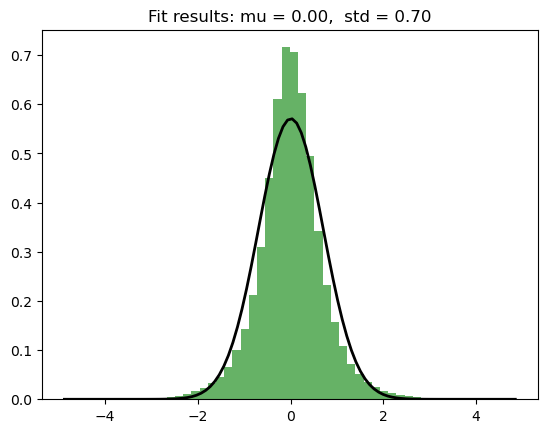

In [73]:
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


### Train multinomial logistic regression

In [74]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [75]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [76]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [77]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.61286277319957

Classification Report:
               precision    recall  f1-score   support

     222_REF       0.15      0.53      0.23       619
     222_TVA       0.91      0.62      0.74      4963

    accuracy                           0.61      5582
   macro avg       0.53      0.58      0.49      5582
weighted avg       0.83      0.61      0.68      5582



### AUC

In [64]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

AUC: 0.6078538535729829


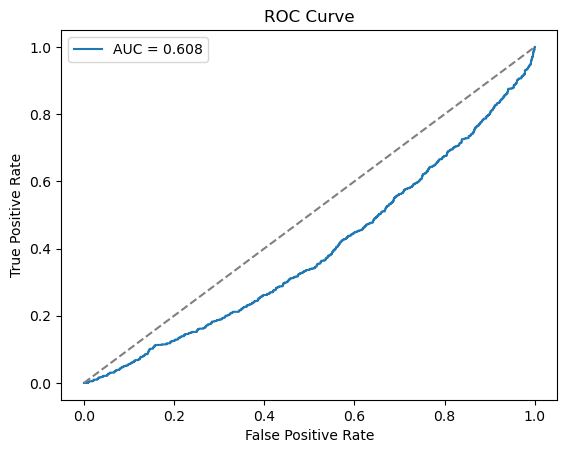

In [87]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [ ]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


# Map clusters to spatial 

In [83]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label
c_2_127_422,4.809296,2.087090,0,0.853239,222_TVA
c_2_127_634,4.312458,1.530603,0,1.000000,222_TVA
c_2_129_104,0.829044,0.198054,-1,0.000000,222_TVA
c_2_129_218,3.347989,2.350463,-1,0.000000,222_TVA
c_2_129_292,-1.061501,-0.455164,-1,0.000000,222_TVA
...,...,...,...,...,...
c_2_152_1629,6.457435,3.477666,0,0.951558,222_REF
c_2_166_303,4.698396,1.025954,0,0.888458,222_REF
c_2_166_314,4.767232,1.016805,0,0.896592,222_REF
c_2_166_348,3.369603,0.826449,-1,0.000000,222_REF


In [84]:
clusters = df_umap['Cluster'].reindex(lrdata.obs_names)
print(f"Missing cluster labels: {clusters.isna().sum()}")

Missing cluster labels: 120681


In [85]:
lrdata.obs['Cluster'] = clusters.astype('category')

/scratch/jobs/37429356/ipykernel_2917803/1180120996.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


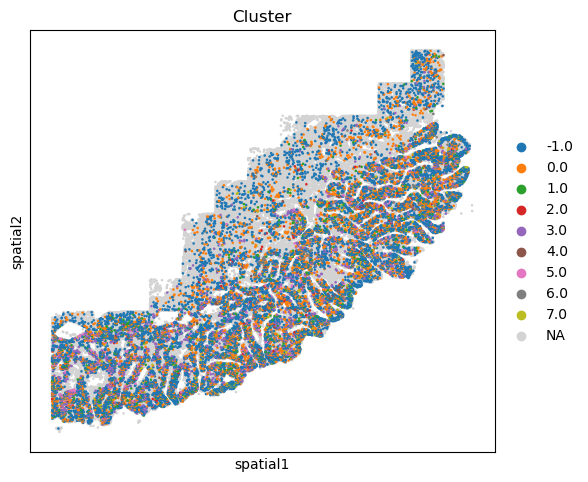

In [86]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='Cluster',
    spot_size=40,
    ax=axes
)
plt.tight_layout()